# Cancer de Piel Deteccion

Lucho Jun | 2023 <br>
Ne me quitte pas by Jaques Brel

El **melanoma**, una forma mortal de **cáncer de piel**, exige un diagnóstico **rápido y preciso**.  
Aprovechando tecnología de última generación, este conjunto de datos permite a investigadores y profesionales desarrollar **modelos de aprendizaje automático** robustos, capaces de distinguir entre **lesiones benignas y malignas**.  
Las imágenes, con un tamaño uniforme de **224 x 224 píxeles**, ofrecen una visión completa de las diversas manifestaciones del melanoma.

---

🌐 Fuentes e Inspiración

Este conjunto de datos surge de la necesidad crítica de herramientas de diagnóstico avanzadas en **dermatología**.  
Las imágenes provienen de **diversas fuentes** y muestran características complejas que desafían los métodos de diagnóstico tradicionales. 

Dataset: https://www.kaggle.com/datasets/bhaveshmittal/melanoma-cancer-dataset


## Import Packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (mean_absolute_error, mean_squared_error,mean_squared_log_error, r2_score,classification_report, confusion_matrix,accuracy_score, precision_score, recall_score, f1_score)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import keras
import tensorflow as tf
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.models import Sequential 
from keras.layers import (BatchNormalization, Conv2D, Dense, Dropout, Flatten,MaxPool2D, MaxPooling2D)

from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image


import pickle
import sklearn
import os
import re

## Import Dataset

In [2]:
# Directorios del conjunto de datos
BASE_DIR = "E:\\Trabajo\\piel_cancer\\"  # Cambia esta ruta según la ubicación de tu conjunto de datos
TRAIN_DIR = os.path.join(BASE_DIR, "train")  # Ruta del directorio de entrenamiento
TEST_DIR = os.path.join(BASE_DIR, "test")    # Ruta del directorio de prueba

# Tamaño de imagen y tamaño del lote (batch)
IMG_SIZE = (224, 224)  # Tamaño óptimo para EfficientNetB0
BATCH_SIZE = 32        # Cantidad de imágenes por lote

In [3]:
# Aumento de datos para el entrenamiento
train_datagen = ImageDataGenerator(
    rescale=1./255,             # Normaliza los valores de los píxeles al rango [0, 1]
    rotation_range=20,          # Rango de rotación aleatoria de las imágenes
    width_shift_range=0.2,      # Desplazamiento horizontal aleatorio
    height_shift_range=0.2,     # Desplazamiento vertical aleatorio
    shear_range=0.2,            # Transformación de corte (shear)
    zoom_range=0.2,             # Zoom aleatorio
    horizontal_flip=True        # Volteo horizontal aleatorio
)

# Solo reescalado para los datos de prueba (sin aumentos)
test_datagen = ImageDataGenerator(rescale=1./255)

# Cargar datos de entrenamiento
train_generator = train_datagen.flow_from_directory(
    directory=TRAIN_DIR,        # Directorio con las imágenes de entrenamiento
    target_size=IMG_SIZE,       # Redimensiona las imágenes al tamaño especificado
    batch_size=BATCH_SIZE,      # Número de imágenes por lote
    class_mode="binary"         # Clasificación binaria: Benigno vs Maligno
)

# Cargar datos de prueba
test_generator = test_datagen.flow_from_directory(
    directory=TEST_DIR,         # Directorio con las imágenes de prueba
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

# Imprimir el mapeo de clases
print("Mapeo de clases:", train_generator.class_indices)

Found 11879 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
Mapeo de clases: {'Benign': 0, 'Malignant': 1}


### Analisis Exploratorio de Datos (EDA)

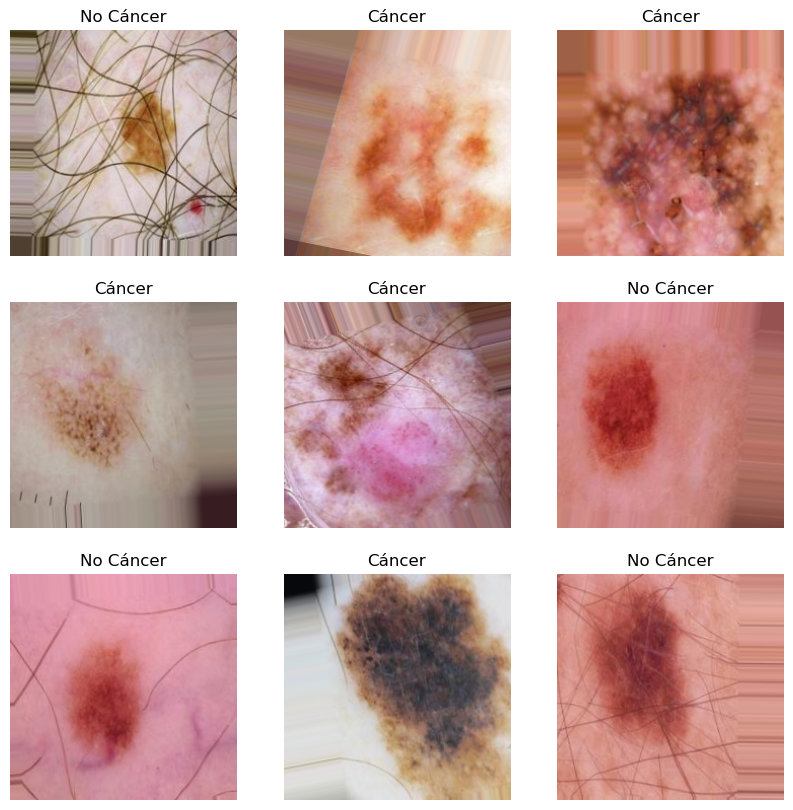

In [4]:
# Mostrar algunas imágenes de ejemplo del conjunto de datos
def plot_images(generator):
    images, labels = next(generator)  # Obtener un lote
    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i])
        plt.title("Cáncer" if labels[i] == 1 else "No Cáncer")
        plt.axis("off")
    plt.show()

# Graficar imágenes de entrenamiento
plot_images(train_generator)


#### Entrenamiento de Modelo

In [5]:
# Construir el modelo CNN
model = models.Sequential([
    # 1ª Capa de Convolución
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),
    
    # 2ª Capa de Convolución
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # 3ª Capa de Convolución
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Capa de Aplanamiento
    layers.Flatten(),
    
    # Capas Completamente Conectadas
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),  # Dropout para reducir el sobreajuste (overfitting)
    layers.Dense(1, activation='sigmoid')  # Capa de salida para clasificación binaria
])

# Compilar el modelo
model.compile(optimizer='adam',  # Optimizador para una convergencia más rápida
              loss='binary_crossentropy',  # Pérdida para clasificación binaria
              metrics=['accuracy'])  # Métrica de precisión

# Resumen del modelo
model.summary()


C:\Users\Lupin III\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,396,609 (169.36 MB)

 Trainable params: 44,396,609 (169.36 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# EarlyStopping para detener el entrenamiento cuando el modelo deja de mejorar
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,  # Detiene el entrenamiento después de 5 épocas sin mejora
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau para reducir la tasa de aprendizaje si el modelo deja de mejorar
lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,  # Reduce la tasa de aprendizaje si no hay mejora después de 3 épocas
    min_lr=1e-7,
    verbose=1
)

# Entrenar el modelo
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=30,  # Número de épocas para entrenar el modelo
    validation_data=test_generator,
    validation_steps=test_generator.samples // BATCH_SIZE,
    callbacks=[early_stopping, lr_scheduler]
)


C:\Users\Lupin III\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
371/371 ━━━━━━━━━━━━━━━━━━━━ 1014s 3s/step - accuracy: 0.6973 - loss: 0.6964 - val_accuracy: 0.7838 - val_loss: 0.4423 - learning_rate: 0.0010
Epoch 2/30
  1/371 ━━━━━━━━━━━━━━━━━━━━ 12:32 2s/step - accuracy: 0.9062 - loss: 0.2659

C:\Users\Lupin III\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


371/371 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.9062 - loss: 0.2659 - val_accuracy: 0.7450 - val_loss: 0.4974 - learning_rate: 0.0010
Epoch 3/30
371/371 ━━━━━━━━━━━━━━━━━━━━ 800s 2s/step - accuracy: 0.8239 - loss: 0.4082 - val_accuracy: 0.8569 - val_loss: 0.3417 - learning_rate: 0.0010
Epoch 4/30
371/371 ━━━━━━━━━━━━━━━━━━━━ 27s 67ms/step - accuracy: 0.8750 - loss: 0.2871 - val_accuracy: 0.8715 - val_loss: 0.3429 - learning_rate: 0.0010
Epoch 5/30
371/371 ━━━━━━━━━━━━━━━━━━━━ 943s 3s/step - accuracy: 0.8308 - loss: 0.3929 - val_accuracy: 0.8438 - val_loss: 0.3512 - learning_rate: 0.0010
Epoch 6/30
  1/371 ━━━━━━━━━━━━━━━━━━━━ 13:54 2s/step - accuracy: 0.9375 - loss: 0.1716
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
371/371 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.9375 - loss: 0.1716 - val_accuracy: 0.8412 - val_loss: 0.3516 - learning_rate: 0.0010
Epoch 7/30
371/371 ━━━━━━━━━━━━━━━━━━━━ 986s 3s/step - accuracy: 0.8476 - loss: 0.3477 - v

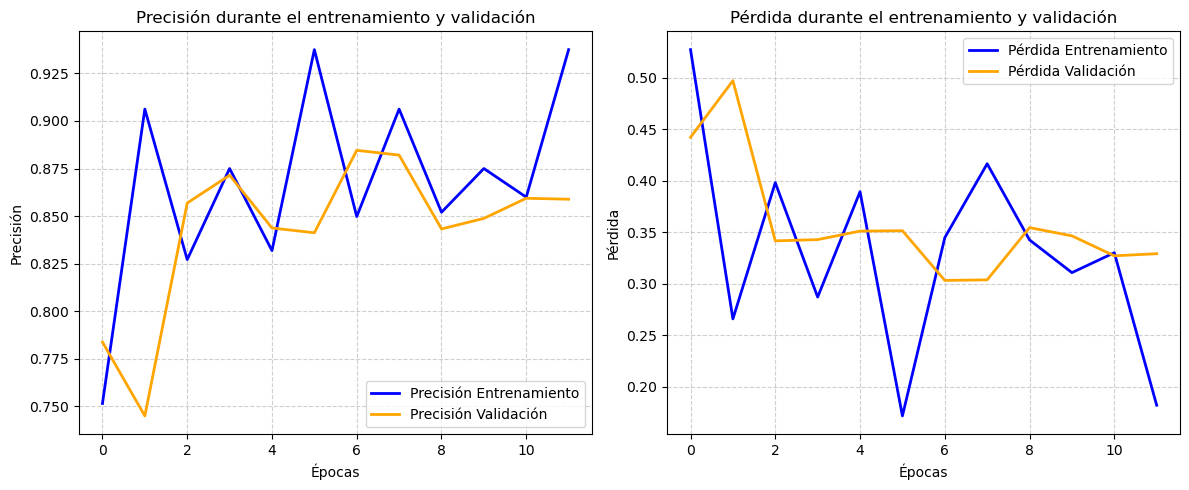

In [7]:
# Guardar el modelo
model.save("skin_cancer_cnn.h5")

plt.figure(figsize=(12, 5))

# Gráfico de Precisión
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Precisión Entrenamiento", color="blue", linewidth=2)
plt.plot(history.history["val_accuracy"], label="Precisión Validación", color="orange", linewidth=2)
plt.title("Precisión durante el entrenamiento y validación")
plt.xlabel("Épocas")
plt.ylabel("Precisión")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="lower right", fontsize=10)

# Gráfico de Pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Pérdida Entrenamiento", color="blue", linewidth=2)
plt.plot(history.history["val_loss"], label="Pérdida Validación", color="orange", linewidth=2)
plt.title("Pérdida durante el entrenamiento y validación")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="upper right", fontsize=10)

plt.tight_layout()
plt.show()

#### Evaluacion de Metricas

62/62 ━━━━━━━━━━━━━━━━━━━━ 31s 493ms/step
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.51      0.52      0.52      1000
           1       0.51      0.50      0.50       984

    accuracy                           0.51      1984
   macro avg       0.51      0.51      0.51      1984
weighted avg       0.51      0.51      0.51      1984



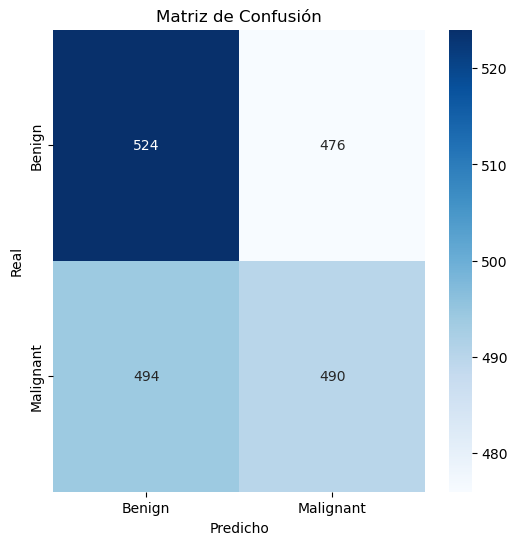

In [8]:
# Realizar predicciones sobre el conjunto de prueba
test_pred = model.predict(test_generator, steps=test_generator.samples // BATCH_SIZE, verbose=1)

# Convertir las predicciones a etiquetas binarias (0 o 1)
test_pred_labels = (test_pred > 0.5).astype("int32")

# Obtener las etiquetas reales
test_true_labels = test_generator.classes[:len(test_pred_labels)]  # Ajustar longitud para que coincida con las predicciones

# Reporte de clasificación
print("Reporte de Clasificación:")
print(classification_report(test_true_labels, test_pred_labels))

# Matriz de confusión
cm = confusion_matrix(test_true_labels, test_pred_labels)

# Graficar la matriz de confusión
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_generator.class_indices.keys(), yticklabels=train_generator.class_indices.keys())
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

In [9]:
# Calcular métricas
accuracy = accuracy_score(test_true_labels, test_pred_labels)
precision = precision_score(test_true_labels, test_pred_labels)
recall = recall_score(test_true_labels, test_pred_labels)
f1 = f1_score(test_true_labels, test_pred_labels)

# Mostrar las métricas
print(f"Exactitud (Accuracy): {accuracy:.4f}")
print(f"Precisión (Precision): {precision:.4f}")
print(f"Recall (Sensibilidad): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Exactitud (Accuracy): 0.5111
Precisión (Precision): 0.5072
Recall (Sensibilidad): 0.4980
F1-Score: 0.5026


#### Comprobacion

In [10]:
# Cargar el modelo completo
model = load_model("E:\\Trabajo\\skin_cancer_cnn.h5")


def predict_skin_cancer(image_path, model):
    img = image.load_img(image_path, target_size=(224, 224))  # Cargar imagen
    img_array = image.img_to_array(img) / 255.0  # Normalizar
    img_array = np.expand_dims(img_array, axis=0)  # Agregar dimensión de lote (batch)

    # Realizar la predicción
    prediction = model.predict(img_array)
    class_label = "Maligno" if prediction > 0.5 else "Benigno"
    
    # Mostrar la imagen con la predicción
    plt.imshow(img)
    plt.title(f"Predicción: {class_label}")
    plt.axis("off")
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step


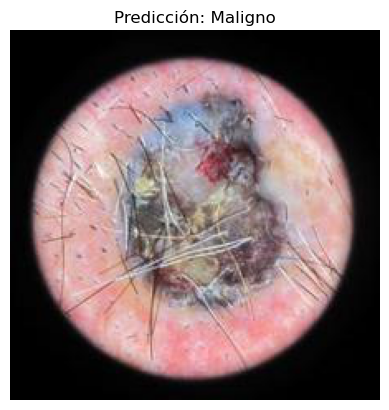

In [11]:
# Test de una nueva imagen
predict_skin_cancer(r"E:\Trabajo\piel_cancer\test\Malignant\5616.jpg", model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


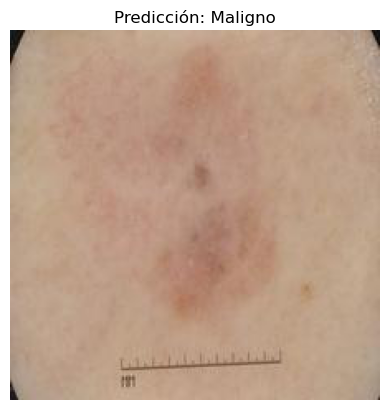

In [12]:
# Test de una nueva imagen
predict_skin_cancer(r"E:\Trabajo\piel_cancer\train\Malignant\1004.jpg", model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


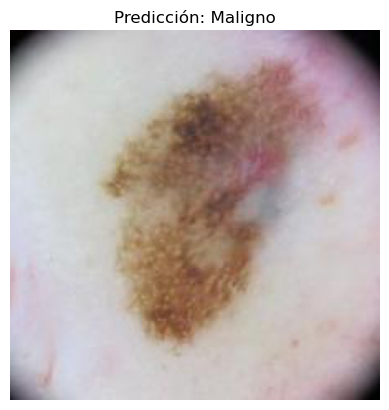

In [13]:
# Test de una nueva imagen
predict_skin_cancer(r"E:\Trabajo\piel_cancer\test\Malignant\5620.jpg", model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


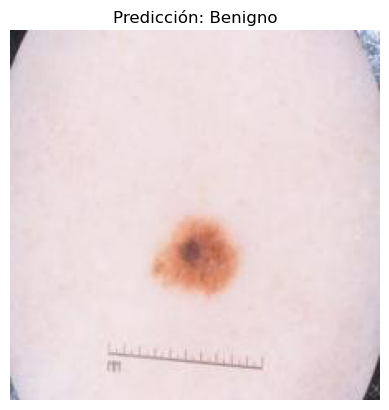

In [14]:
# Test de una nueva imagen
predict_skin_cancer(r"E:\Trabajo\piel_cancer\test\Malignant\5879.jpg", model)